In [1]:
import cv2
import numpy as np
 

In [ ]:


def video_to_grayscale(mp4_path: str) -> np.ndarray:
    """
    Read an MP4 file and return a 3D numpy array of grayscale brightness values.

    Args:
        mp4_path: Path to the input .mp4 file.

    Returns:
        np.ndarray of shape (height, width, num_frames), dtype uint8.
        Each value is the average of the red and green channels at that pixel/frame.

    Raises:
        ValueError: If the file cannot be opened or contains no frames.
    """
    cap = cv2.VideoCapture(mp4_path)

    if not cap.isOpened():
        raise ValueError(f"Could not open video file: {mp4_path}")

    num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    if num_frames <= 0 or width <= 0 or height <= 0:
        cap.release()
        raise ValueError(f"Could not read valid dimensions from: {mp4_path}")

    # Pre-allocate output array — avoids any list building or stacking
    out = np.empty((height, width, num_frames), dtype=np.uint8)

    # mix_mat: weights applied per-pixel across BGR channels → (0*B + 0.5*G + 0.5*R)
    # cv2.transform multiplies each pixel's [B, G, R] vector by this 1x3 matrix in one C call
    mix_mat = np.array([[0, 0.5, 0.5]], dtype=np.float32)

    actual_frames = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # cv2.transform applies mix_mat row-wise across all pixels — stays in C, no Python loops
        gray = cv2.transform(frame, mix_mat)  # shape: (H, W, 1), float32
        out[:, :, actual_frames] = gray[:, :]
        actual_frames += 1

    cap.release()

    if actual_frames == 0:
        raise ValueError(f"No frames could be read from: {mp4_path}")

    # Trim in case CAP_PROP_FRAME_COUNT over-reported (common with some codecs)
    if actual_frames < num_frames:
        out = out[:, :, :actual_frames]

    return out

In [10]:
arr = video_to_grayscale("Raja vs Wijemanne short.mp4")
print(arr.shape)   # (height, width, num_frames)
print(arr.dtype)   # uint8

# Access frame 0
frame_0 = arr[:, :, 0]

(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)
(1080, 1920)

In [5]:
diff = np.diff(arr.astype(np.int16), axis=2)

In [4]:
np.save("short_video_array.npy", arr)

In [15]:
import matplotlib.pyplot as plt

In [2]:
arr

NameError: name 'arr' is not defined

In [4]:
arr = np.load("short_video_array.npy")

In [13]:
diff = np.diff(arr.astype(np.int16), axis=2)

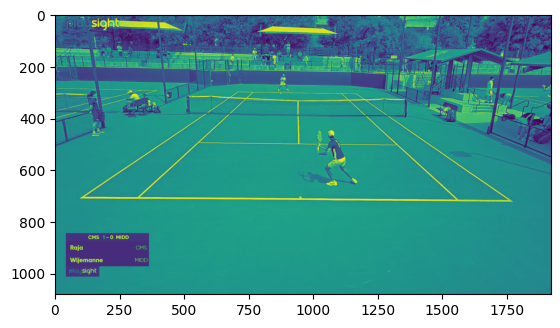

In [ ]:
plt.imshow(arr[:,:,100])

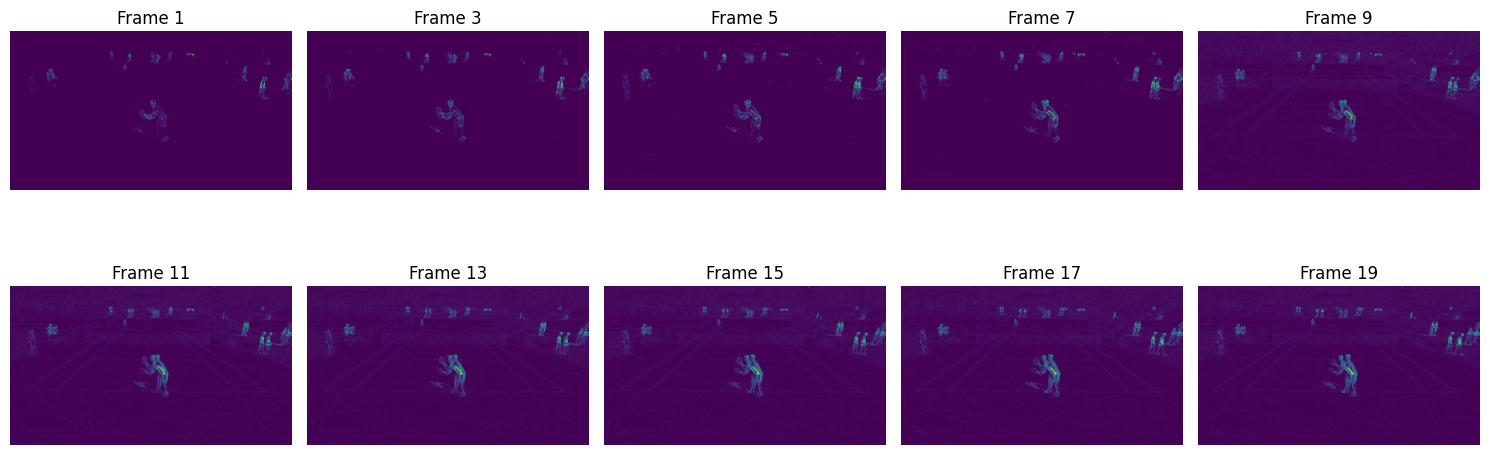

In [40]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.abs(arr[:, :, i*2+1].astype(np.int16) - arr[:,:,0].astype(np.int16)))
    ax.set_title(f"Frame {i*2+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

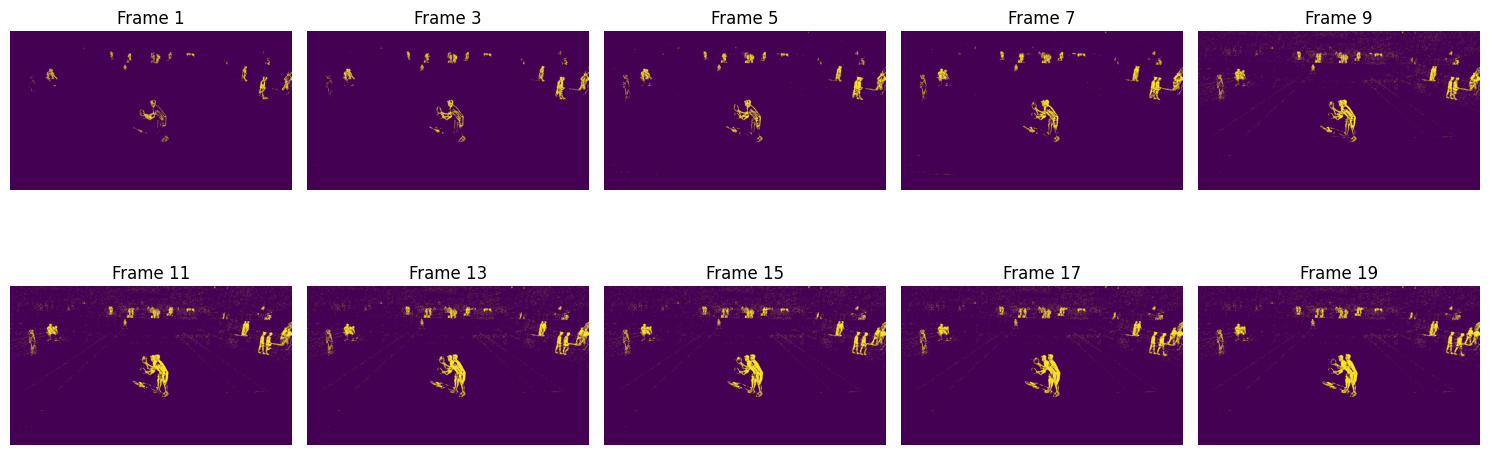

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    diffi = np.abs(arr[:, :, i*2+1].astype(np.int16) - arr[:,:,0].astype(np.int16))
    ax.imshow(diffi>20)
    ax.set_title(f"Frame {i*2+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(1920, 10)),
 array([-212. , -168.9, -125.8,  -82.7,  -39.6,    3.5,   46.6,   89.7,
         132.8,  175.9,  219. ]),
 <a list of 1920 BarContainer objects>)

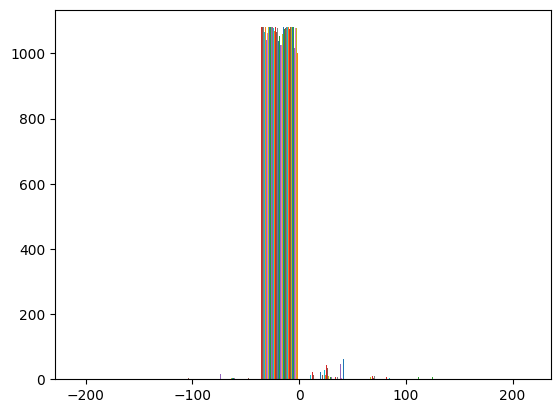

In [39]:
plt.hist(diff[:,:,1])

In [8]:
diffi>30

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(1080, 1920))

In [20]:

def array_to_mp4(frames: np.ndarray, output_path: str, resize = (640,360), fps: float = 30.0) -> None:
    """
    Convert a greyscale numpy array to an mp4 video.

    Args:
        frames:      Array of shape (height, width, n_frames), dtype uint8 or float.
                     Float arrays are expected in [0.0, 1.0] and will be scaled to uint8.
        output_path: Destination path, e.g. 'output.mp4'.
        fps:         Frames per second (default 30).
    """
    height, width, n_frames = frames.shape

    # Normalize float arrays to uint8
    # if frames.dtype != np.uint8:
    #     frames = (np.clip(frames, 0.0, 1.0) * 255).astype(np.uint8)
    


    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_path, fourcc, fps, resize, isColor=True)

    if not writer.isOpened():
        raise RuntimeError(f"Could not open VideoWriter for path: {output_path}")

    for i in range(n_frames):
        grey = frames[:, :, i].astype(np.uint8)              # (H, W), uint8
        grey = cv2.resize(grey, resize)
        bgr  = cv2.cvtColor(grey, cv2.COLOR_GRAY2BGR)  # cv2 needs 3-channel
        writer.write(bgr)

    writer.release()
    print(f"Saved {n_frames} frames → {output_path}  ({width}×{height} @ {fps} fps)")

In [21]:
array_to_mp4(diff, "diff_video_short.mp4")

KeyboardInterrupt: 

In [10]:
def detect_tennis_ball(frame,
                      min_area=20,
                      max_area=500,
                      min_circularity=0.5,
                      debug=False):
    """
    Detect likely tennis ball positions in a frame.

    Args:
        frame: BGR or grayscale image (ideally a differential frame).
        min_area: Minimum blob area in pixels.
        max_area: Maximum blob area in pixels.
        min_circularity: Filter for how circular the blob is (0–1).
        debug: If True, returns debug image as well.

    Returns:
        List of detections: [(x, y, radius, score), ...]
        If debug=True, also returns a visualization image.
    """

    # Convert to grayscale if needed
    if len(frame.shape) == 3:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    else:
        gray = frame.copy()

    # Blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Threshold for bright regions (adaptive can also work)
    _, thresh = cv2.threshold(blurred, 200, 255, cv2.THRESH_BINARY)

    # Morphological cleanup
    kernel = np.ones((3, 3), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    cleaned = cv2.dilate(cleaned, kernel, iterations=1)

    # Find contours (blobs)
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    detections = []
    debug_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue

        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0:
            continue

        # Circularity = 4π * area / perimeter²
        circularity = 4 * np.pi * area / (perimeter * perimeter)

        if circularity < min_circularity:
            continue

        (x, y), radius = cv2.minEnclosingCircle(cnt)

        # Mean brightness inside contour (optional scoring)
        mask = np.zeros(gray.shape, dtype=np.uint8)
        cv2.drawContours(mask, [cnt], -1, 255, -1)
        mean_val = cv2.mean(gray, mask=mask)[0]

        score = mean_val * circularity

        detections.append((int(x), int(y), int(radius), score))

        if debug:
            cv2.circle(debug_img, (int(x), int(y)), int(radius), (0, 255, 0), 2)
            cv2.putText(debug_img, f"{score:.1f}", (int(x), int(y)-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,255,0), 1)

    # Sort by score (best first)
    detections.sort(key=lambda d: d[3], reverse=True)

    if debug:
        return detections, debug_img

    return detections

In [12]:
detections = detect_tennis_ball(diff[:,:,0].astype(np.uint8))

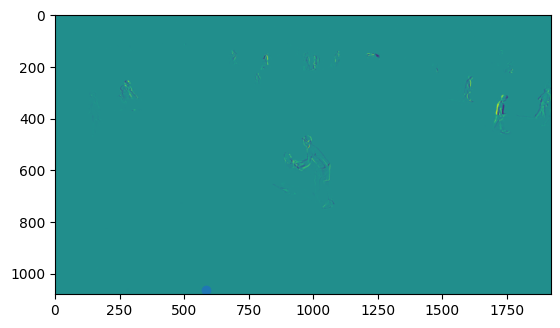

In [17]:
plt.imshow(diff[:,:,0])
plt.scatter(detections[0][0], detections[0][1])